<a href="https://colab.research.google.com/github/Quantum00000/Kaggle_Compititions/blob/main/Rainfall_Prediction_Advanced_Regression_Techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [182]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [183]:
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_5266d2b9f41bb08f77787f1fc1d7ce93'

In [184]:
mkdir -p ~/.kaggle && echo KGAT_5266d2b9f41bb08f77787f1fc1d7ce93 > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [185]:
import kagglehub
path = kagglehub.competition_download('for-house-prices-advanced-regression-techniques-you-can-us')


In [186]:
print(os.listdir(path))

['train.csv', 'sample_submission.csv', 'test.csv']


In [187]:
train_data=pd.read_csv(os.path.join(path,'train.csv'))

In [188]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2190 entries, 0 to 2189
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             2190 non-null   int64  
 1   day            2190 non-null   int64  
 2   pressure       2190 non-null   float64
 3   maxtemp        2190 non-null   float64
 4   temparature    2190 non-null   float64
 5   mintemp        2190 non-null   float64
 6   dewpoint       2190 non-null   float64
 7   humidity       2190 non-null   float64
 8   cloud          2190 non-null   float64
 9   sunshine       2190 non-null   float64
 10  winddirection  2190 non-null   float64
 11  windspeed      2190 non-null   float64
 12  rainfall       2190 non-null   int64  
dtypes: float64(10), int64(3)
memory usage: 222.6 KB


In [189]:
train_data

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2185,2185,361,1014.6,23.2,20.6,19.1,19.9,97.0,88.0,0.1,40.0,22.1,1
2186,2186,362,1012.4,17.2,17.3,16.3,15.3,91.0,88.0,0.0,50.0,35.3,1
2187,2187,363,1013.3,19.0,16.3,14.3,12.6,79.0,79.0,5.0,40.0,32.9,1
2188,2188,364,1022.3,16.4,15.2,13.8,14.7,92.0,93.0,0.1,40.0,18.0,1


In [190]:
print(train_data.isnull().sum())

id               0
day              0
pressure         0
maxtemp          0
temparature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
sunshine         0
winddirection    0
windspeed        0
rainfall         0
dtype: int64


In [191]:
train=train_data[train_data["day"]<=219]
val=train_data[train_data["day"]>219]

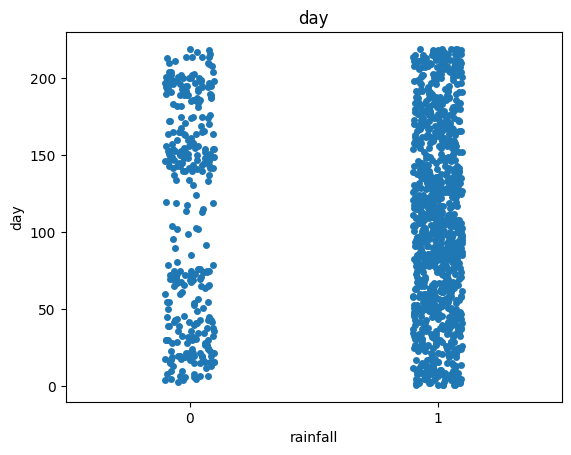

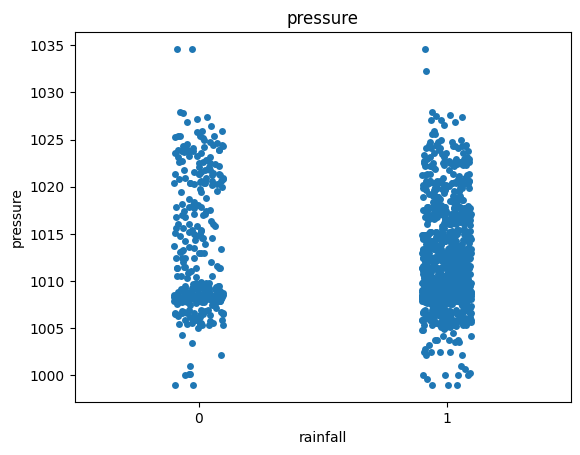

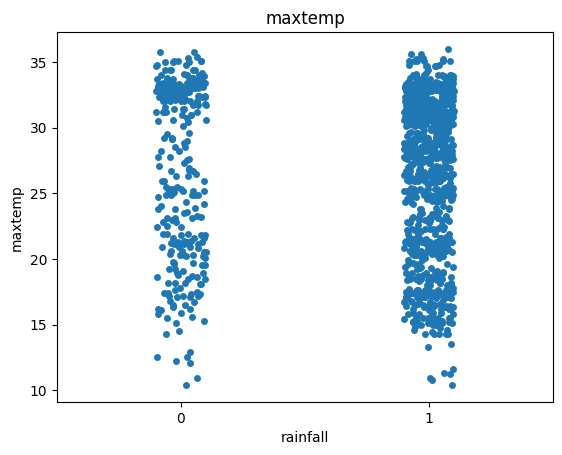

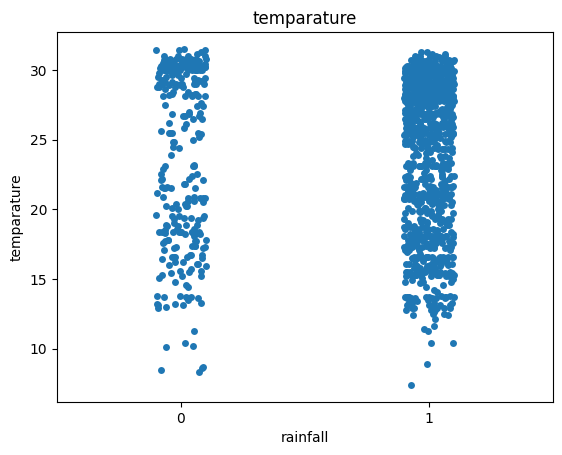

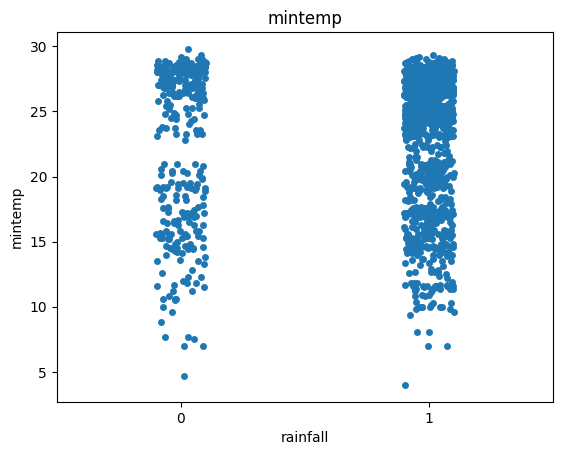

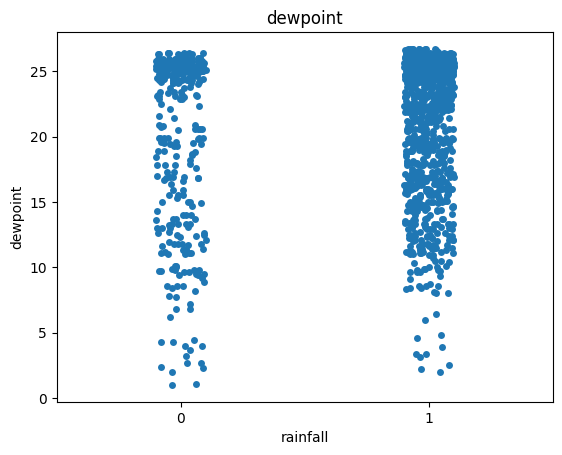

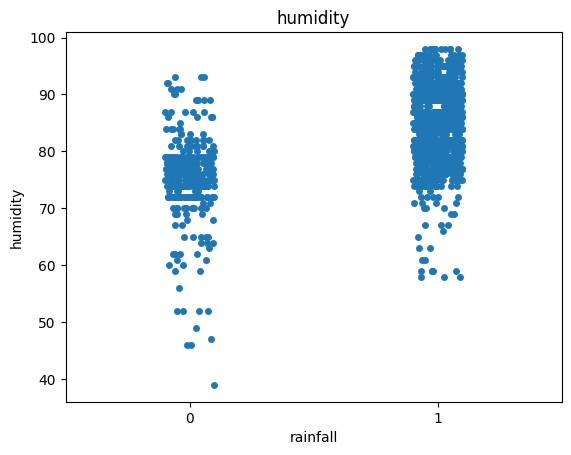

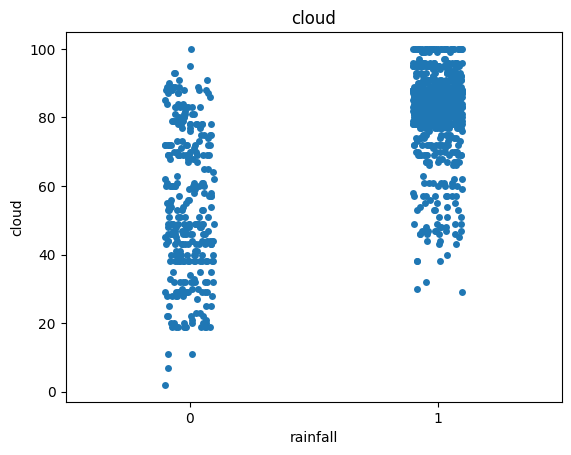

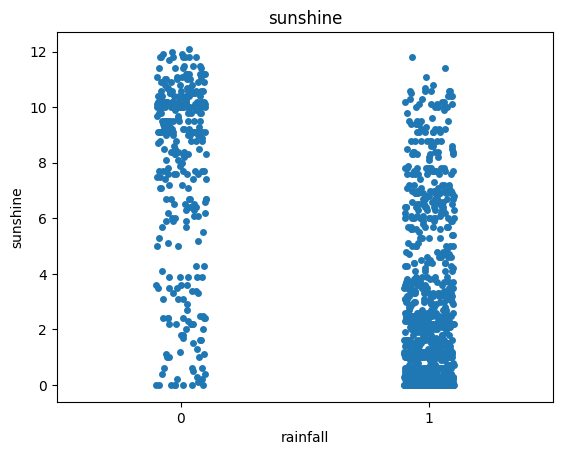

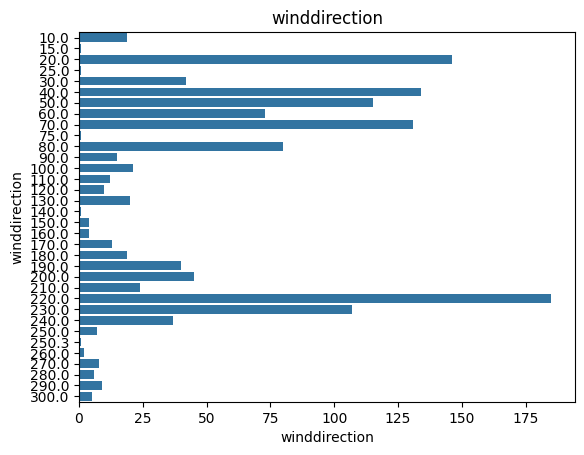

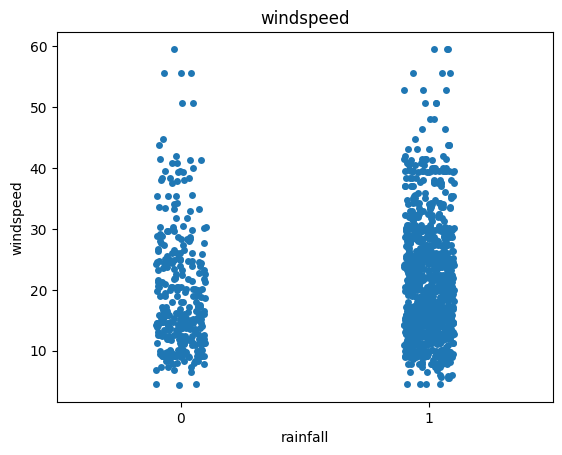

In [192]:
for labels in train.columns[1:12]:
  if(labels=="winddirection"):
    plt.figure()
    sns.countplot(data=train,y=labels)
    plt.title(labels)
    plt.xlabel("winddirection")
    plt.ylabel(labels)
    plt.show()
  else:
    plt.figure()
    sns.stripplot(x="rainfall",y=labels,data=train)
    plt.title(labels)
    plt.xlabel("rainfall")
    plt.ylabel(labels)
    plt.show()

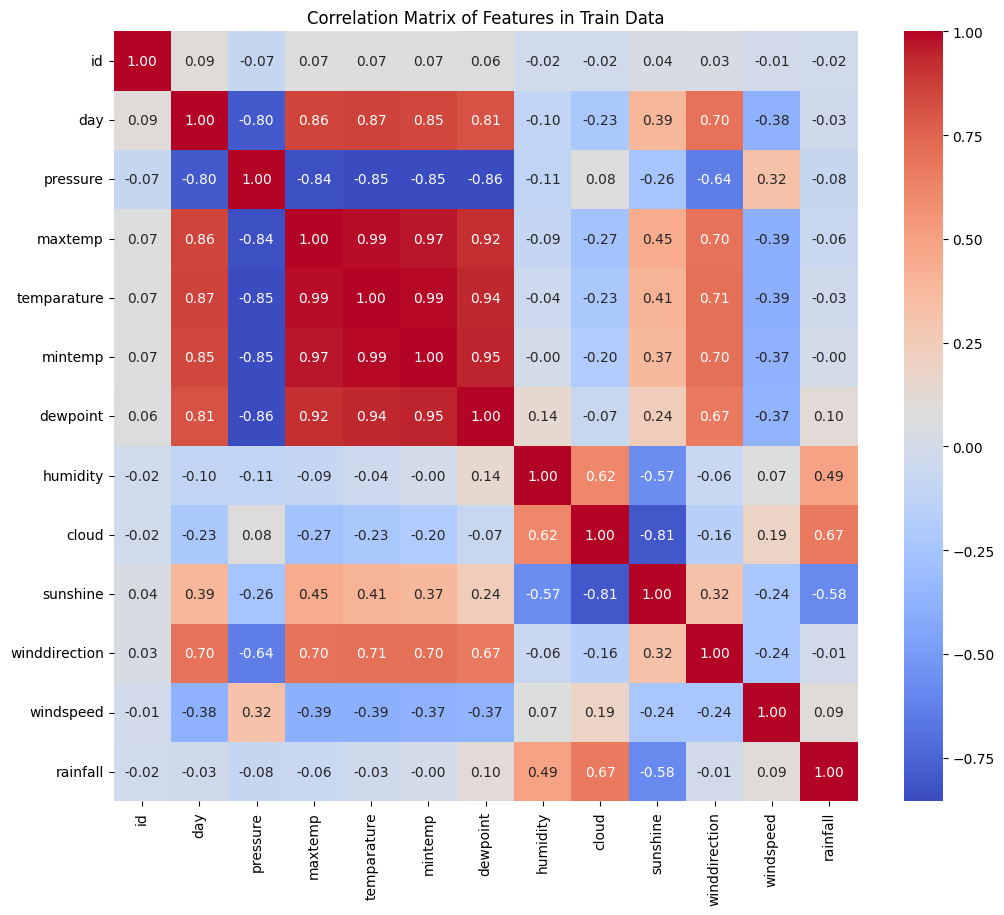

In [193]:
correlation_matrix = train.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features in Train Data')
plt.show()

In [194]:
train_data = train_data.drop(columns=["mintemp"])

In [195]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [196]:
x_train=train_data.drop(columns=["rainfall"])
y_train=train_data["rainfall"]

In [197]:
#Decision Tree Classifier

model= DecisionTreeClassifier()
model.fit(x_train,y_train)

DecisionTreeClassifier()

In [198]:
val=val.drop(columns=["mintemp"])

In [199]:
x_val=val.drop(columns=["rainfall"])
y_val=val["rainfall"]

In [200]:
predict01=model.predict(x_val)

In [201]:
from sklearn.metrics import accuracy_score

In [202]:
accuracy=accuracy_score(predict01,y_val)

In [203]:
accuracy

1.0

In [204]:
test_data=pd.read_csv(os.path.join(path,'test.csv'))

In [205]:
test_data=test_data.drop(columns=["mintemp"])

In [206]:
predict_test01=model.predict(test_data)

In [207]:
predict_test01

array([1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1,

In [208]:
sample_submission=pd.read_csv(os.path.join(path,'sample_submission.csv'))

SUBMISSION

In [209]:
sample_submission

,id,rainfall
0,2190,0
1,2191,0
2,2192,0
3,2193,0
4,2194,0
...,...,...
725,2915,0
726,2916,0
727,2917,0
728,2918,0


In [210]:
sub_data=pd.DataFrame({'id': test_data['id'],'rainfall': predict_test01})

In [211]:
sub_data.to_csv('submission.csv', index=False)

In [212]:
sub_data

,id,rainfall
0,2190,1
1,2191,1
2,2192,0
3,2193,0
4,2194,0
...,...,...
725,2915,1
726,2916,1
727,2917,1
728,2918,1


RANDOM FOREST CLASSIFIER

In [213]:
model02=RandomForestClassifier()


In [214]:
model02.fit(x_train,y_train)

RandomForestClassifier()

In [215]:
predict02=model02.predict(x_val)

In [216]:
accuracy_score(predict02,y_val)

1.0

In [217]:
predict_test02=model02.predict(test_data)

In [218]:
sub_data02=pd.DataFrame({'id': test_data['id'],'rainfall': predict_test02})

In [219]:
sub_data02.to_csv('submission02.csv',index=False)